## Assignment 01 - EN3160
### Fernando H.M.D. - 230180F

Question 01

In [1]:
# Intensity transformation functions
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q1.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [2]:
def intensity_transform(im, breakpoints):

    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    im_float = im.astype(np.float32)
    transformed = np.zeros_like(im_float)

    # Piecewise linear interpolation
    lut = np.zeros(256, dtype=np.float32)

    intensity_values = np.arange(256, dtype=np.float32)

    # Process each pair of consecutive breakpoints
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x1 == x2:
            continue

        # Intensities lying on this segment
        mask = (
            (intensity_values >= x1) &
            (intensity_values <= x2)
        )

        lut[mask] = (
            y1
            + (y2 - y1) *
            (intensity_values[mask] - x1) /
            (x2 - x1)
        )
        
    # At repeated x-values, use the value AFTER the jump
    for i in range(len(breakpoints) - 1):
        if x[i] == x[i + 1]:
            jump_x = int(x[i])
            lut[jump_x] = y[i + 1]

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[im]


In [3]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [200, 200],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)


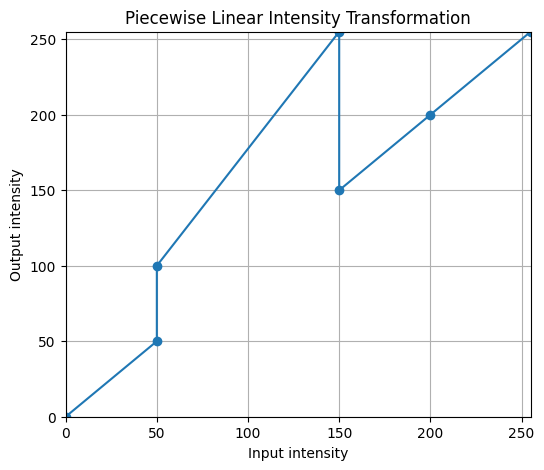

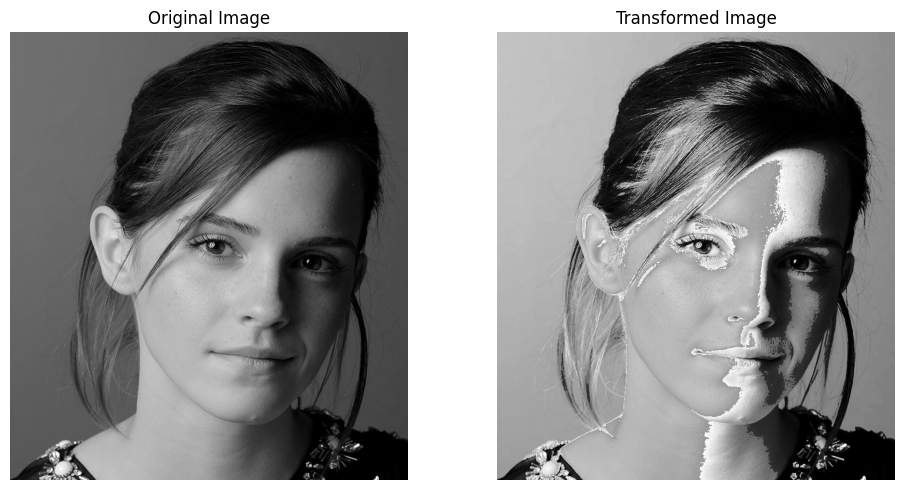

In [4]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

For a visually pleasing output

In [5]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 100],
    [150, 150],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)

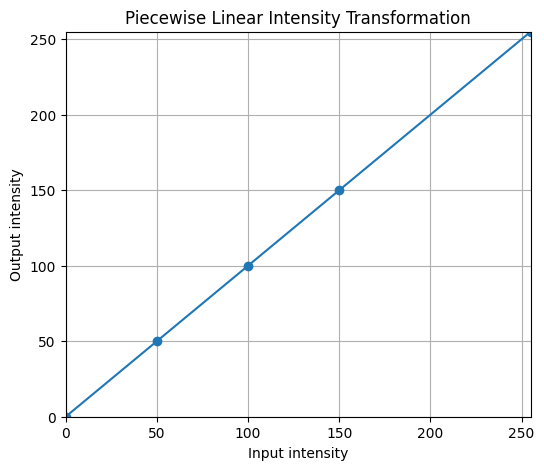

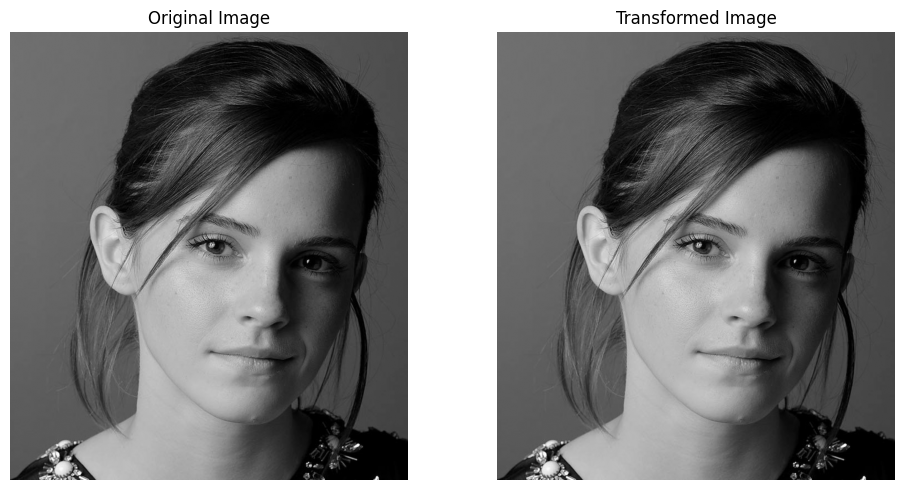

In [6]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Question 2

In [9]:
img = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q2.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

print("image shape", img.shape)

image shape (217, 181)


White matter and Gray matter in a brain proton density image does not mean the places with high pixel intensities and lower areas. rather, White and Gray matter means seperate areas of tissue.

To find the pixel intensities of the designated areas, we can inspect biological areas of white and gray matter. We can inspect that the gray matter is in the region of Y[80:90], X[30:40]... the wrinkly outer tissue of the brain. And the white matter is roughly Y[100:120] X[50:70] region. The white range in the middle is not white matter. that is CSF region.

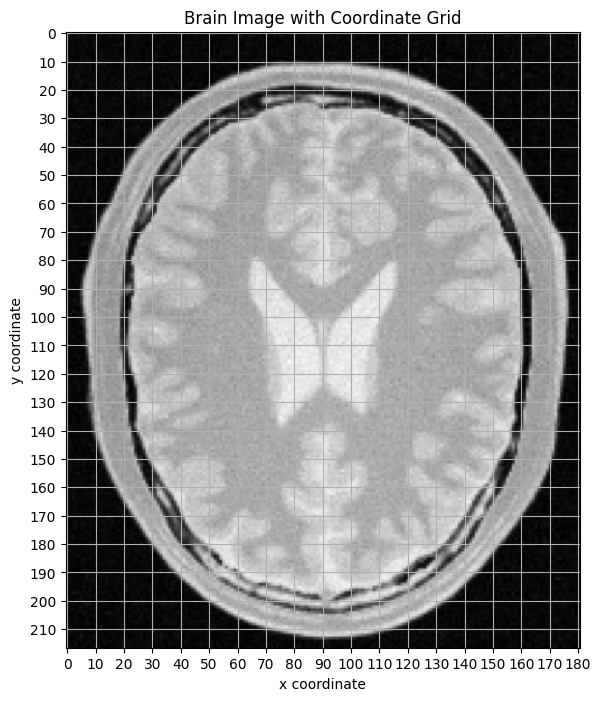

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(img, cmap="gray", vmin=0, vmax=255)

plt.xticks(range(0, img.shape[1], 10))
plt.yticks(range(0, img.shape[0], 10))

plt.grid(True)

plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.title("Brain Image with Coordinate Grid")

plt.show()

In [24]:
white_roi = img[100:120, 50:60]

print("White matter mean:", np.mean(white_roi))
print("White matter min :", np.min(white_roi))
print("White matter max :", np.max(white_roi))

gray_roi = img[150:160, 40:50]

print("Gray matter mean:", np.mean(gray_roi))
print("Gray matter min :", np.min(gray_roi))
print("Gray matter max :", np.max(gray_roi))

White matter mean: 167.21
White matter min : 148
White matter max : 194
Gray matter mean: 196.85
Gray matter min : 171
Gray matter max : 222


Now, I am using Gaussian pulse as the intensity transformation function to accentuate only the required range of pixel intensities. The reason to use Gaussian pulse rather than block pixels is to remove the jump discontinuities and obtain a smooth contrast from the rest of the image. The white matter is centered arounf 167.21 ~ 165 and gray matter is centered arounf 196.85 ~ 200. Such is the value of miu. As for sigma, sigma reflects the range of values that will be accentuated.

In [31]:
def gaussian_intensity_transform(im, mu, sigma):
    x = np.arange(256)

    # Create transformation
    T = 255 * np.exp(
        -((x - mu) ** 2) / (2 * sigma ** 2)
    )

    T = np.clip(T, 0, 255).astype(np.uint8)

    # Apply lookup table to image
    transformed = T[im]

    return transformed, T

In [38]:
white_matter, T_white = gaussian_intensity_transform(
    img, mu=165, sigma=15
)

gray_matter, T_gray = gaussian_intensity_transform(
    img, mu=200, sigma=15
)

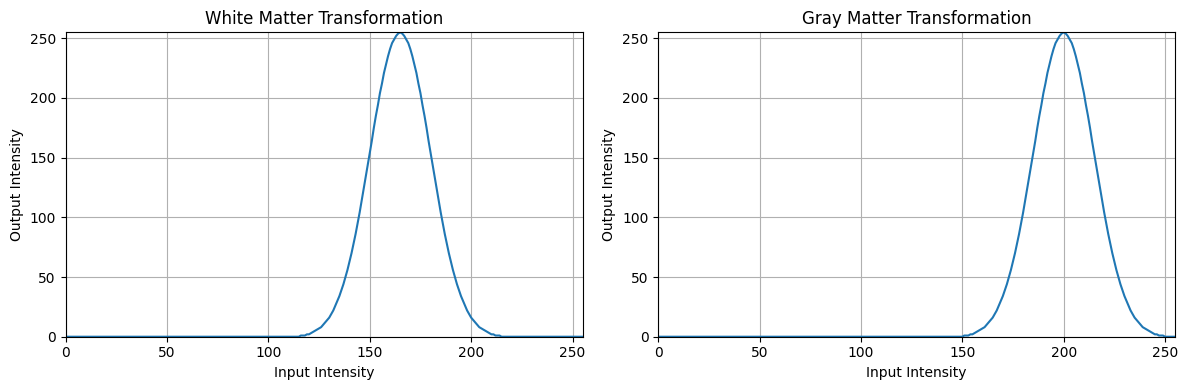

In [39]:
x = np.arange(256)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, T_white)
axes[0].set_title("White Matter Transformation")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid()

axes[1].plot(x, T_gray)
axes[1].set_title("Gray Matter Transformation")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid()

plt.tight_layout()
plt.show()

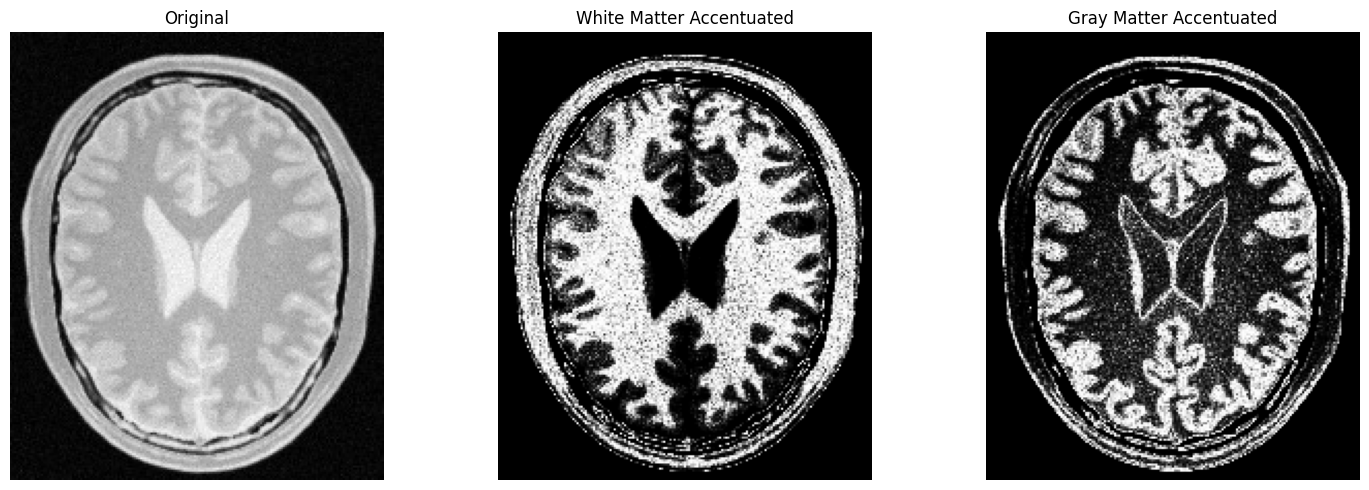

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(white_matter, cmap="gray")
axes[1].set_title("White Matter Accentuated")

axes[2].imshow(gray_matter, cmap="gray")
axes[2].set_title("Gray Matter Accentuated")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()